# DeliveryETA — Étape 3 : Transformation des données et entraînement des modèles

Objectif : encoder les variables catégorielles, séparer train/test, normaliser, puis entraîner et comparer
4 modèles de régression sur les mêmes données.

In [7]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/processed/dataset_delivery_time_model_ready.csv")
print(df.shape)
df.head()

(41706, 15)


,Delivery_person_Age,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Distance_km,Preparation_time_min,Order_hour,Day_of_week,Is_weekend
0,37.0,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24.0,3.025149,15.0,11,5,1
1,34.0,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33.0,20.183530,5.0,19,4,0
2,23.0,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26.0,1.552758,15.0,8,5,1
3,38.0,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21.0,7.790401,10.0,18,1,0
4,32.0,Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30.0,6.210138,15.0,13,5,1


## 1. Encodage des variables catégorielles

**Justification par variable** :
- `Road_traffic_density` (`Low` < `Medium` < `High` < `Jam`) : les modalités ont un ordre naturel de gravité
  -> `OrdinalEncoder` avec un ordre explicite (0, 1, 2, 3), qui préserve cette gradation. Un one-hot ferait
  perdre cette information d'ordre.
- `Weatherconditions`, `Type_of_order`, `Type_of_vehicle`, `City` : pas d'ordre naturel entre les modalités
  -> `OneHotEncoder`.
- `Festival` (binaire No/Yes) : `OneHotEncoder(drop="if_binary")` pour n'obtenir qu'une seule colonne 0/1 au
  lieu de deux colonnes parfaitement redondantes (colinéarité inutile pour les modèles linéaires).

L'encodage est fait à l'intérieur d'un `ColumnTransformer`, lui-même dans un `Pipeline` scikit-learn : il sera
donc *entraîné uniquement sur le train* et seulement *appliqué* (transform) sur le test, ce qui évite toute
fuite de données (le test ne doit jamais influencer les statistiques d'encodage/normalisation).

In [9]:
TARGET = "Time_taken(min)"

numeric_cols = [
    "Distance_km",
    "Preparation_time_min",
    "Order_hour",
    "Day_of_week",
    "Is_weekend",
    "multiple_deliveries",
    "Vehicle_condition",
    "Delivery_person_Age"
      ]
ordinal_cols = ["Road_traffic_density"]
nominal_cols = [
    "Weatherconditions",
    "Type_of_vehicle",
    "Festival",
    "City" ,
    "Type_of_order"
]

traffic_order = [["Low", "Medium", "High", "Jam"]]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols),
    ("ord", OrdinalEncoder(categories=traffic_order), ordinal_cols),
    ("nom", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), nominal_cols),
])
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

## 2. Séparation train (80 %) / test (20 %)

**Justification** : split classique 80/20, `random_state` fixé pour la reproductibilité. Le split se fait
*avant* tout fit du préprocesseur ou d'un modèle, afin que le test reste une évaluation honnête sur des
données jamais vues.

In [ ]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train :", X_train.shape, " Test :", X_test.shape)

Preprocessor created successfully.
ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Distance_km', 'Preparation_time_min',
                                  'Order_hour', 'Day_of_week', 'Is_weekend',
                                  'multiple_deliveries', 'Vehicle_condition',
                                  'Delivery_person_Age']),
                                ('ord',
                                 OrdinalEncoder(categories=[['Low', 'Medium',
                                                             'High', 'Jam']]),
                                 ['Road_traffic_density']),
                                ('nom',
                                 OneHotEncoder(drop='if_binary',
                                               handle_unknown='ignore'),
                                 ['Weatherconditions', 'Type_of_vehicle',
                                  'Festival', 'City', 'Type_of_order'])])


## 3. Normalisation des variables numériques

**Justification du choix StandardScaler (plutôt que MinMaxScaler)** : plusieurs variables numériques
(`Distance_km`, `Preparation_time_min`) restent légèrement asymétriques même après le nettoyage de l'étape 1.
`StandardScaler` centre sur la moyenne et normalise par l'écart-type, ce qui est plus robuste qu'un
`MinMaxScaler` (très sensible aux valeurs min/max, donc à un futur point extrême non vu à l'entraînement).
C'est indispensable pour `LinearRegression` (sensible à l'échelle des variables) ; neutre pour les modèles à
base d'arbres (invariants aux transformations monotones), donc appliquer le même scaler à tous les modèles ne
pénalise personne et simplifie le pipeline (une seule transformation pour tous).

## 4. Entraînement et comparaison de 4 modèles

4 modèles volontairement variés :
- **LinearRegression** : baseline linéaire simple.
- **DecisionTree** : capture des relations non linéaires, mais mémorise facilement le train (bon exemple de
  surapprentissage, discuté à l'étape 4).
- **RandomForest** : ensemble d'arbres (bagging), généralise mieux qu'un arbre seul.
- **GradientBoosting** : ensemble séquentiel (boosting), souvent compétitif sur des données tabulaires.

Les 4 modèles sont entraînés sur exactement le même `X_train`/`y_train` et évalués sur le même
`X_test`/`y_test`, via le même préprocesseur (encapsulé dans un `Pipeline` par modèle) pour une comparaison
strictement équitable.

In [11]:
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Lasso, Ridge


models = {
    "LinearRegression": LinearRegression(),

    "Ridge": Ridge(alpha=1.0),

    "Lasso": Lasso(alpha=0.001),

    "DecisionTree": DecisionTreeRegressor(
        random_state=42
    ),

    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingRegressor(
        random_state=42
    ),

    "HistGradientBoosting": HistGradientBoostingRegressor(
        random_state=42
    ),
}

def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred),
    }

rows = []
fitted_pipelines = {}
for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    test_metrics = evaluate(y_test, pipe.predict(X_test))
    train_metrics = evaluate(y_train, pipe.predict(X_train))

    rows.append({
        "model": name,
        "MAE": test_metrics["MAE"], "MSE": test_metrics["MSE"],
        "RMSE": test_metrics["RMSE"], "R2_test": test_metrics["R2"],
        "R2_train": train_metrics["R2"],
    })

results = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
results

,model,MAE,MSE,RMSE,R2_test,R2_train
0,HistGradientBoosting,3.339005,17.169895,4.143657,0.796630,0.808469
1,RandomForest,3.392583,18.148259,4.260077,0.785042,0.970191
2,ExtraTrees,3.474838,19.389955,4.403403,0.770334,1.000000
3,GradientBoosting,3.869014,23.672104,4.865399,0.719614,0.722881
4,DecisionTree,4.473747,33.870295,5.819819,0.598821,1.000000
5,LinearRegression,5.139514,41.488115,6.441127,0.508591,0.515530
6,Ridge,5.139577,41.488536,6.441160,0.508586,0.515530
7,Lasso,5.140169,41.494325,6.441609,0.508517,0.515516


## 5. Interprétation des résultats

### Résultats obtenus (sur ce split)

| Modèle                   |      MAE |     RMSE |   R² test |  R² train |
| ------------------------ | -------: | -------: | --------: | --------: |
| **HistGradientBoosting** | **3.34** | **4.14** | **0.797** | **0.808** |
| RandomForest             |     3.39 |     4.26 |     0.785 |     0.970 |
| ExtraTrees               |     3.47 |     4.40 |     0.770 |     1.000 |
| GradientBoosting         |     3.87 |     4.87 |     0.720 |     0.723 |
| DecisionTree             |     4.47 |     5.82 |     0.599 |     1.000 |
| LinearRegression         |     5.14 |     6.44 |     0.509 |     0.516 |
| Ridge                    |     5.14 |     6.44 |     0.509 |     0.516 |
| Lasso                    |     5.14 |     6.44 |     0.509 |     0.516 |

### Lecture métier

Le modèle **HistGradientBoosting** obtient les meilleures performances sur l'ensemble de test.

Son **MAE de 3,34 minutes** signifie qu'en moyenne, la prédiction du temps de livraison s'écarte d'environ **3,3 minutes** de la valeur réelle.

Son **RMSE de 4,14 minutes** indique également une erreur moyenne relativement faible, tout en pénalisant davantage les erreurs importantes.

Avec un **R² test de 0,797**, le modèle explique environ **79,7 % de la variance** du temps de livraison sur cet ensemble de test.

### Analyse du surapprentissage

Les résultats montrent des différences importantes entre certains modèles.

**HistGradientBoosting** présente un R² de **0,808 sur le train** contre **0,797 sur le test**, soit un écart d'environ **0,012**. Cet écart relativement faible indique que le modèle généralise de manière assez stable sur les données de test.

**RandomForest** obtient un bon R² test de **0,785**, mais son R² train atteint **0,970**. L'écart entre train et test est donc beaucoup plus important, ce qui indique un **surapprentissage plus marqué**.

**ExtraTrees** et **DecisionTree** ont tous les deux un R² train de **1,00**, alors que leurs performances sur le test sont respectivement de **0,770** et **0,599**. Cette différence importante entre train et test est un signe de **surapprentissage**.

**GradientBoosting** présente un écart très faible entre le train (**0,723**) et le test (**0,720**), ce qui montre une bonne stabilité. Cependant, ses performances restent inférieures à celles de HistGradientBoosting.

Les modèles **LinearRegression, Ridge et Lasso** ont des performances proches, avec un R² test d'environ **0,509**. Leur faible écart entre train et test montre qu'ils ne présentent pas de surapprentissage important, mais leurs performances sont inférieures aux modèles basés sur les arbres. Cela suggère que les relations entre les variables et le temps de livraison sont probablement plus complexes qu'une simple relation linéaire.

### Modèle retenu pour l'optimisation

Pour l'étape suivante, le modèle **HistGradientBoosting** est retenu comme modèle à optimiser.

Il présente sur ce split :

* **MAE : 3,34 minutes**
* **RMSE : 4,14 minutes**
* **R² test : 0,797**
* **R² train : 0,808**
* **Écart train/test : environ 0,012**

Ces résultats montrent un bon compromis entre **précision sur les données de test et stabilité entre l'entraînement et le test**.

L'étape suivante consistera à effectuer une **optimisation des hyperparamètres** et une **validation croisée** afin de vérifier si ces performances restent stables sur plusieurs découpages des données.


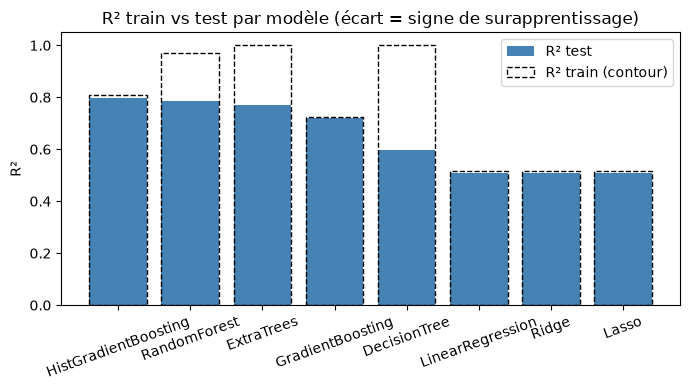

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(results["model"], results["R2_test"], color="steelblue", label="R² test")
ax.bar(results["model"], results["R2_train"], color="none", edgecolor="black",
       linestyle="--", label="R² train (contour)")
ax.set_ylabel("R²")
ax.set_title("R² train vs test par modèle (écart = signe de surapprentissage)")
ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [15]:
results.to_csv("../models/model_comparison_step3.csv", index=False)
print("Comparatif sauvegardé.")

Comparatif sauvegardé.
